# DGGS aspect-ratio survey

For `N` random cells at the finest resolution of three discrete global grid
systems — **H3**, **S2**, **A5** — compute the tightest enclosing-cone aspect
ratio with `skar`, then plot the per-system distribution and the best/worst
cell with its enclosing ellipse.

Single-pass: a generator streams one cell at a time, each is solved
immediately, and only the running aggregates are kept. `N` is set in the next
cell — raise it for smoother histograms.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

import a5_fast as a5  # Rust/PyO3 A5 binding (~30x faster than pya5)
import h3
import s2sphere

import skar

In [2]:
# How many random cells to sample per system. Raise for smoother histograms
# (cost is ~linear; A5 cell generation dominates the wall-clock).
N = 5000

SEED = 0xC0FFEE
GAP_TOL = 1e-3   # looser than skar's strict 1e-6: sub-metre cells floor the
                 # duality gap there, so 1e-3 lets every cell converge

H3_RES = 15                 # h3 supports 0..15
S2_LEVEL = 30               # s2sphere supports 0..30
A5_RES = 30  # a5.MAX_RESOLUTION (a5_fast has no constant)

SYSTEMS = ['h3', 's2', 'a5']
SYS_LABEL = {'h3': 'H3 r15', 's2': 'S2 L30', 'a5': 'A5 r30'}
SYS_COLOR = {'h3': 'C0', 's2': 'C1', 'a5': 'C2'}
EARTH_R_M = 6_371_008.8     # scale gnomonic (dimensionless) coords to metres

Per-system cell streams: sample uniform points, snap each to its containing
cell, dedupe, and yield the cell's boundary as a unit-vector array.
`run_system` solves every cell and keeps the aspect ratios plus the most- and
least-circular cell.

In [3]:
def sample_uniform_lonlat(n, rng):
    """Uniform-on-sphere samples as (lon, lat) degrees, shape (n, 2)."""
    lon = 360.0 * rng.random(n) - 180.0
    lat = np.degrees(np.arcsin(2.0 * rng.random(n) - 1.0))  # equal-area in lat
    return np.column_stack([lon, lat])


def iter_h3(n, seed):
    rng = np.random.default_rng(seed)
    seen = set()
    for lon, lat in sample_uniform_lonlat(n, rng):
        cid = h3.latlng_to_cell(float(lat), float(lon), H3_RES)
        if cid in seen:
            continue
        seen.add(cid)
        yield cid, skar.to_vec3(h3.cell_to_boundary(cid), geo='latlng')


def iter_s2(n, seed):
    rng = np.random.default_rng(seed)
    seen = set()
    for lon, lat in sample_uniform_lonlat(n, rng):
        cid = s2sphere.CellId.from_lat_lng(s2sphere.LatLng.from_degrees(float(lat), float(lon)))
        if S2_LEVEL != 30:
            cid = cid.parent(S2_LEVEL)
        if cid.id() in seen:
            continue
        seen.add(cid.id())
        cell = s2sphere.Cell(cid)
        v = np.array([tuple(cell.get_vertex(i))[:3] for i in range(4)], dtype=float)
        v /= np.linalg.norm(v, axis=1, keepdims=True)  # corners aren't unit length
        yield format(cid.id(), '016x'), v


def iter_a5(n, seed):
    rng = np.random.default_rng(seed)
    seen = set()
    for lon, lat in sample_uniform_lonlat(n, rng):
        cid = a5.lonlat_to_cell(float(lon), float(lat), A5_RES)
        if cid in seen:
            continue
        seen.add(cid)
        ring = a5.cell_to_boundary(cid)  # closed ring of (lon, lat)
        if len(ring) >= 2 and tuple(ring[0]) == tuple(ring[-1]):
            ring = ring[:-1]
        latlng = [(lat_, lon_) for lon_, lat_ in ring]
        yield a5.u64_to_hex(cid), skar.to_vec3(latlng, geo='latlng_deg')


ITERATORS = {'h3': iter_h3, 's2': iter_s2, 'a5': iter_a5}


def run_system(name):
    """Stream every cell, solve it, keep aspect ratios + the two extremes."""
    ars, dnc, best, worst = [], 0, None, None
    for cid, verts in ITERATORS[name](N, SEED):
        r = skar.solve(verts, geo='vec3', gap_tol=GAP_TOL)
        if not isinstance(r, skar.Converged):
            dnc += 1
            continue
        rec = {'ar': r.aspect_ratio, 'id': cid, 'verts': verts, 'result': r}
        ars.append(r.aspect_ratio)
        if best is None or rec['ar'] < best['ar']:
            best = rec
        if worst is None or rec['ar'] > worst['ar']:
            worst = rec
    return {'ars': np.asarray(ars), 'dnc': dnc, 'best': best, 'worst': worst}

Run the survey — one pass per system:

In [4]:
results = {}
for s in SYSTEMS:
    t0 = time.perf_counter()
    results[s] = run_system(s)
    print(f'[{s}] {results[s]["ars"].size} cells in {time.perf_counter() - t0:.2f}s '
          f'(DNC {results[s]["dnc"]})')

[h3] 5000 cells in 0.07s (DNC 0)
[s2] 5000 cells in 0.09s (DNC 0)
[a5] 5000 cells in 2.56s (DNC 0)


### Aspect-ratio distributions

Shared bins, log-count y-axis. H3 hugs 1 (near-circular), S2 spreads through the
middle, and A5 is tightly clustered around 2:1 — its cells are never circular.

sys         n       min    median       p99       max
h3       5000    1.0000    1.0529    1.2057    1.2554
s2       5000    1.0020    1.2248    1.6081    1.7262
a5       5000    1.9873    2.1341    2.2961    2.3154


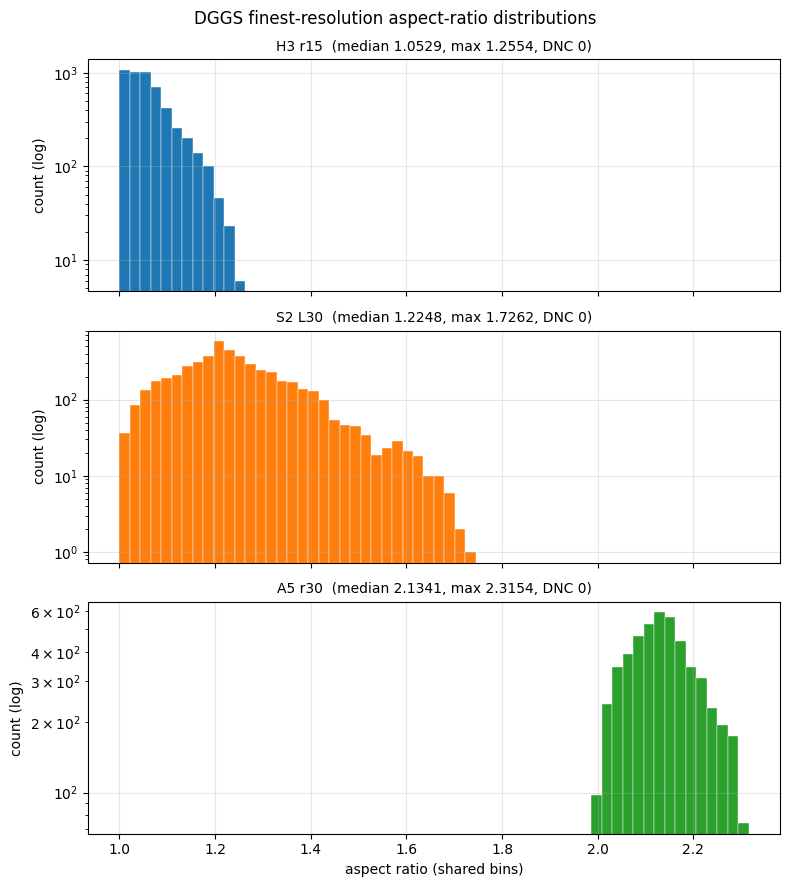

In [5]:
ars = {s: results[s]['ars'] for s in SYSTEMS}


def stat(a):
    return dict(n=a.size, min=float(a.min()), median=float(np.median(a)),
                p99=float(np.percentile(a, 99)), max=float(a.max()))


st = {s: stat(ars[s]) for s in SYSTEMS}
print(f'{"sys":5} {"n":>7} {"min":>9} {"median":>9} {"p99":>9} {"max":>9}')
for s in SYSTEMS:
    d = st[s]
    print(f'{s:5} {d["n"]:>7} {d["min"]:>9.4f} {d["median"]:>9.4f} '
          f'{d["p99"]:>9.4f} {d["max"]:>9.4f}')

bins = np.linspace(1.0, max(a.max() for a in ars.values()), 61)
fig, axes = plt.subplots(len(SYSTEMS), 1, figsize=(8, 9), sharex=True)
for ax, s in zip(axes, SYSTEMS):
    d = st[s]
    ax.hist(ars[s], bins=bins, color=SYS_COLOR[s], edgecolor='white', linewidth=0.3)
    ax.set_yscale('log')  # AR clusters near the low end with a thin tail
    ax.set_ylabel('count (log)')
    ax.set_title(f'{SYS_LABEL[s]}  (median {d["median"]:.4f}, max {d["max"]:.4f}, '
                 f'DNC {results[s]["dnc"]})', fontsize=10)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('aspect ratio (shared bins)')
fig.suptitle('DGGS finest-resolution aspect-ratio distributions')
fig.tight_layout()

### Best vs worst cell

The most-circular (best) and most-elongated (worst) cell per system,
gnomonic-projected at the cone axis with the enclosing-cone cross-section
ellipse overlaid (major axis horizontal).

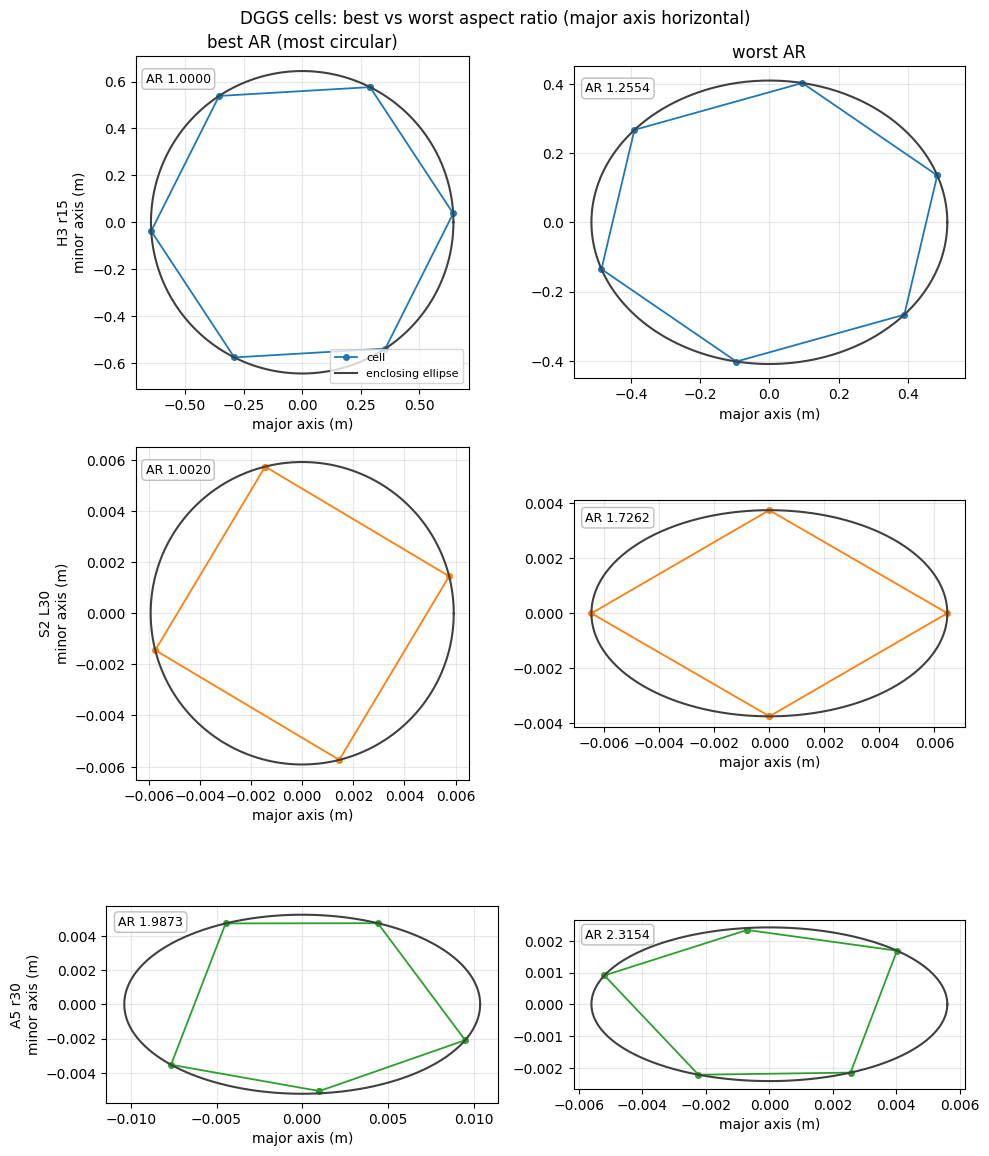

In [6]:
def draw_cell(ax, rec, color):
    r = rec['result']
    b, U = r.Q[:, 0], r.Q[:, 1:]
    semi = np.sqrt(1.0 - r.sigma[0] ** 2) / r.sigma[1:] * EARTH_R_M  # (major, minor)
    y = (rec['verts'] @ U) / (rec['verts'] @ b)[:, None] * EARTH_R_M  # gnomonic
    ring = np.vstack([y, y[:1]])
    t = np.linspace(0.0, 2.0 * np.pi, 400)
    ax.plot(ring[:, 0], ring[:, 1], '-o', color=color, lw=1.3, ms=4, label='cell')
    ax.plot(semi[0] * np.cos(t), semi[1] * np.sin(t), '-', color='0.25', lw=1.5,
            label='enclosing ellipse')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.text(0.03, 0.95, f'AR {rec["ar"]:.4f}', transform=ax.transAxes, va='top',
            fontsize=9, bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.85))


fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes[0, 0].set_title('best AR (most circular)', fontsize=12)
axes[0, 1].set_title('worst AR', fontsize=12)
for row, s in enumerate(SYSTEMS):
    for col, kind in ((0, 'best'), (1, 'worst')):
        ax = axes[row, col]
        draw_cell(ax, results[s][kind], SYS_COLOR[s])
        ax.set_xlabel('major axis (m)')
        if col == 0:
            ax.set_ylabel(f'{SYS_LABEL[s]}\nminor axis (m)')
axes[0, 0].legend(loc='lower right', fontsize=8)
fig.suptitle('DGGS cells: best vs worst aspect ratio (major axis horizontal)')
fig.tight_layout()